# Vector Embeddings

In this notebook, we will be using SBERT - Sentence Transformaers to create the embeddings and learn about them by getting the hands dirty. It can be used to generate embeddings for Text, Audio, Impages or Video. To learn more about it, please follow the dowcumentation at: https://sbert.net/

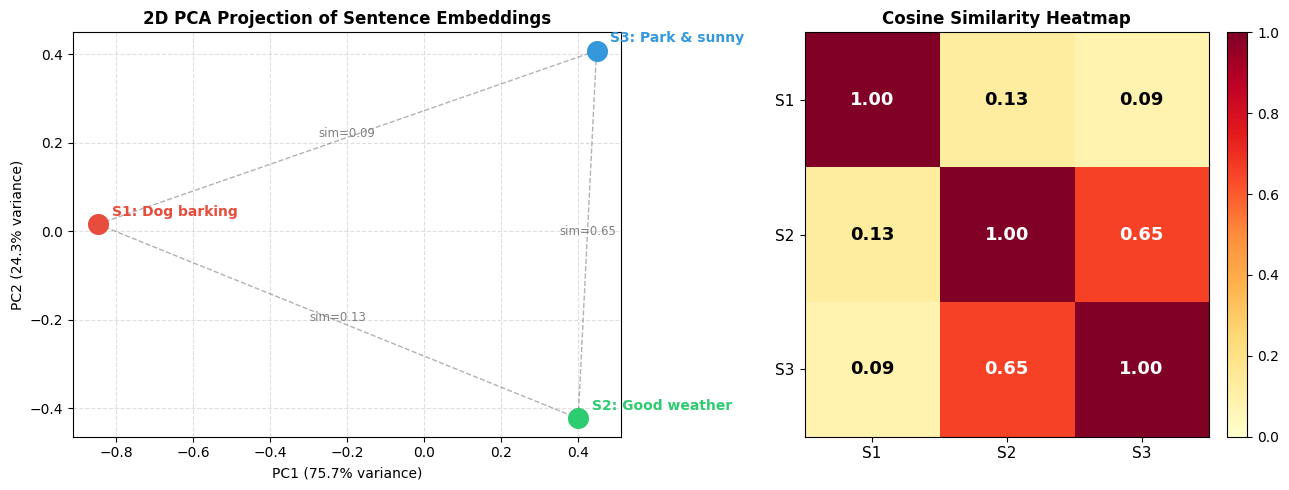

| | |
|:-|-:|
| [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NavneetSinghArora/AI-From-Scratch/blob/main/src/vector-embeddings.ipynb) | [![View on GitHub](https://img.shields.io/badge/View_on-GitHub-black?logo=github)](https://github.com/NavneetSinghArora/AI-From-Scratch/blob/main/src/vector-embeddings.ipynb) |

In [1]:
# Installing the packages

! uv pip install -U sentence-transformers

Using Python 3.14.2 environment at: /Users/navneet/Workspace/AI-From-Scratch/.venv
Resolved 39 packages in 333ms                                        
Audited 39 packages in 1ms


In [ ]:
# Import necessary Libraries

import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer
from dotenv import load_dotenv

/Users/navneet/Workspace/AI-From-Scratch/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Local dev: load from .env file
load_dotenv()

# Colab: read from Colab Secrets (Add your HF_TOKEN via Tools > Secrets)
if os.getenv("HF_TOKEN") is None and "google.colab" in sys.modules:
    from google.colab import userdata
    try:
        os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
        print("✅ Hugging Face token loaded from Colab Secrets.")
    except Exception:
        print("⚠️ HF_TOKEN not found in Colab Secrets. Continuing without authentication.")
        print("   Tip: add it via Tools > Secrets in the Colab menu.")

## Load the Model

Lets first load the pretrained model which will be used to create the embeddings. There are multiple models available which can be used for this tas. To know more about them, please refer to: https://sbert.net/docs/sentence_transformer/pretrained_models.html

In [4]:
# 1. Load a pretrained Sentence Transformer model
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11685.83it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
#  Create the text or sentences that you want to encode
sentences = [
    "My dog is barking and running around.",
    "The weather is really good and sunny today.",
    "I am going to the part to enjoy nice and sunny weather."
]

In [6]:
# 2. Calculate embeddings by calling model.encode()
embeddings = model.encode(sentences)

# Lets check the encodings
print(f"The shape of the embeddings is: {embeddings.shape}")
print(f"The type of the embeddings is: {type(embeddings)}")
print(f"The embedding dimensions are: {len(embeddings[0])}")
print(f"The first sentence embedding is: {embeddings[0]}")


The shape of the embeddings is: (3, 384)
The type of the embeddings is: <class 'numpy.ndarray'>
The embedding dimensions are: 384
The first sentence embedding is: [ 5.44272773e-02 -2.82799974e-02  7.80213624e-02  6.06270954e-02
  3.32837403e-02 -3.80046479e-02 -2.08263155e-02 -7.06758201e-02
  3.51581126e-02 -5.33161163e-02 -2.63785925e-02 -5.87993488e-02
  5.89283407e-02  7.52148554e-02  1.96933374e-02  3.49084288e-03
 -2.50223223e-02 -1.41030652e-02  1.85430720e-02 -9.96479169e-02
 -4.01011929e-02  1.04146615e-01  2.53458470e-02 -3.31039503e-02
 -9.95900109e-02  5.66498861e-02  3.67869213e-02 -7.88689256e-02
 -2.72236206e-02 -1.86648276e-02 -1.86923686e-02 -1.13493696e-01
  6.78092707e-03  3.93816121e-02  1.24959573e-02 -2.95289718e-02
 -4.04161960e-03  1.08561702e-02  7.58087784e-02  5.47643714e-02
  6.11813292e-02  3.31249945e-02  7.09922388e-02 -6.56811446e-02
 -3.74954268e-02  5.04733529e-03 -7.57836252e-02 -7.04468638e-02
  9.95320678e-02 -3.22731286e-02 -2.10606139e-02  5.47063

As you can see in the output above, the shape of the embeddings is (3, 384).
Here, 
    3 represents the 3 sentences which we are trying to encode.
    384 represents the embedding dimensions (This can be seen from the embedding length of the first sentence above)

This kind of vector embeddings are known as Dense Vector Embeddings

## Sentence Similarity

Using the embeddings of the encoded sentences, we will now check the similarities between them all.

In [7]:
# 3. Calculate the embedding similarities
similarities = model.similarity(embeddings, embeddings)

# Lets check which sentences are similar to each other and which ones are not.
print(f"The similarities between the sentences are: \n {similarities}")

The similarities between the sentences are: 
 tensor([[1.0000, 0.1262, 0.0851],
        [0.1262, 1.0000, 0.6537],
        [0.0851, 0.6537, 1.0000]])


Here the similarity tensor suggest the similarity of self vs other sentences. 
As you can see that the self similarity is rated as 1.0 which represents complete match. Whereas a low number (sentence 1 and 2 = 0.1262) shows low similarity while a high number (sentence 2 and 3) represents high similarity. This is evident from the sentences as the last two sentences talk about the weather while the first one is completely different semantically.

## Visualizing the Embeddings

Since each embedding has 384 dimensions, we can't plot them directly. We'll use **PCA** (Principal Component Analysis) to reduce them to 2D and see if the spatial layout matches what the similarity scores tell us — sentences 2 and 3 should cluster together, while sentence 1 should sit farther away.

We'll also plot a **similarity heatmap** for a cleaner view of the pairwise scores.

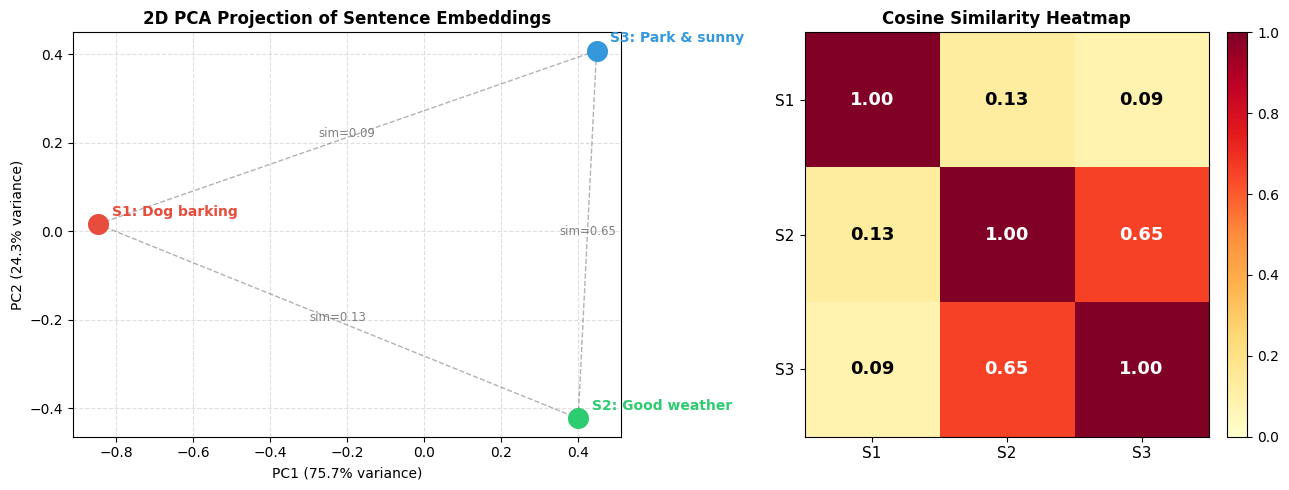


Key observations:
  S2 ↔ S3 similarity: 0.6537  ← HIGH  (both about sunny weather)
  S1 ↔ S2 similarity: 0.1262  ← LOW   (dog vs weather)
  S1 ↔ S3 similarity: 0.0851  ← LOW   (dog vs park/weather)

PCA variance explained: 100.0% in 2 components


In [ ]:
# --- Reduce embeddings to 2D via PCA ---
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# Short labels for each sentence
labels = [
    "S1: Dog barking",
    "S2: Good weather",
    "S3: Park & sunny",
]

# Similarity matrix as a plain numpy array
sim_matrix = similarities.numpy()

# --- Layout: scatter on left, heatmap on right ---
fig = plt.figure(figsize=(13, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1])

# ── Scatter plot ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
colors = ["#e74c3c", "#2ecc71", "#3498db"]

for i, (x, y) in enumerate(embeddings_2d):
    ax1.scatter(x, y, color=colors[i], s=200, zorder=3)
    ax1.annotate(
        labels[i],
        (x, y),
        textcoords="offset points",
        xytext=(10, 6),
        fontsize=10,
        color=colors[i],
        fontweight="bold",
    )

# Draw lines between all pairs, annotated with similarity score
pairs = [(0, 1), (0, 2), (1, 2)]
for i, j in pairs:
    x_vals = [embeddings_2d[i][0], embeddings_2d[j][0]]
    y_vals = [embeddings_2d[i][1], embeddings_2d[j][1]]
    ax1.plot(x_vals, y_vals, "k--", alpha=0.3, linewidth=1)
    mid_x = np.mean(x_vals)
    mid_y = np.mean(y_vals)
    ax1.text(
        mid_x, mid_y,
        f"sim={sim_matrix[i][j]:.2f}",
        fontsize=8.5, color="gray", ha="center",
    )

ax1.set_title("2D PCA Projection of Sentence Embeddings", fontsize=12, fontweight="bold")
ax1.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax1.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax1.grid(True, linestyle="--", alpha=0.4)

# ── Heatmap ───────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
short = ["S1", "S2", "S3"]
im = ax2.imshow(sim_matrix, cmap="YlOrRd", vmin=0, vmax=1)

for i in range(3):
    for j in range(3):
        ax2.text(j, i, f"{sim_matrix[i][j]:.2f}", ha="center", va="center",
                 fontsize=13, fontweight="bold",
                 color="white" if sim_matrix[i][j] > 0.6 else "black")

ax2.set_xticks([0, 1, 2])
ax2.set_yticks([0, 1, 2])
ax2.set_xticklabels(short, fontsize=11)
ax2.set_yticklabels(short, fontsize=11)
ax2.set_title("Cosine Similarity Heatmap", fontsize=12, fontweight="bold")
plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("\nKey observations:")
print(f"  S2 ↔ S3 similarity: {sim_matrix[1][2]:.4f}  ← HIGH  (both about sunny weather)")
print(f"  S1 ↔ S2 similarity: {sim_matrix[0][1]:.4f}  ← LOW   (dog vs weather)")
print(f"  S1 ↔ S3 similarity: {sim_matrix[0][2]:.4f}  ← LOW   (dog vs park/weather)")
print(f"\nPCA variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}% in 2 components")

## The Math Behind the Magic: Manual Cosine Similarity
   2 While we can use `model.similarity()`, it's important to understand that the "Similarity" is just math. Specifically, it's the **Cosine Similarity**.
   3
   4 The formula for Cosine Similarity between two vectors $A$ and $B$ is:
   5 $$\text{similarity} = \cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|}$$

In [9]:

def manual_cosine(v1, v2):
    # Dot product
    dot_product = np.dot(v1, v2)
    # Magnitudes (L2 Norms)
    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)

    return dot_product / (norm_v1 * norm_v2)
   
# Compare S2 and S3 (The weather sentences)
sim_manual = manual_cosine(embeddings[1], embeddings[2])
print(f"Manual Cosine Similarity (S2 vs S3): {sim_manual:.4f}")
print(f"SBERT Cosine Similarity (S2 vs S3): {similarities[1][2]:.4f}")

Manual Cosine Similarity (S2 vs S3): 0.6537
SBERT Cosine Similarity (S2 vs S3): 0.6537


## Visualizing L2 Normalization
"Normalization" is important as it squishes vectors to a length of 1. Carefull here, it is the length and not the dimensions.
Let's visualize this in 2D.

We will take some random 2D vectors, plot them, then normalize them and see how they all "snap" to the **Unit Circle** (a circle with radius 1)

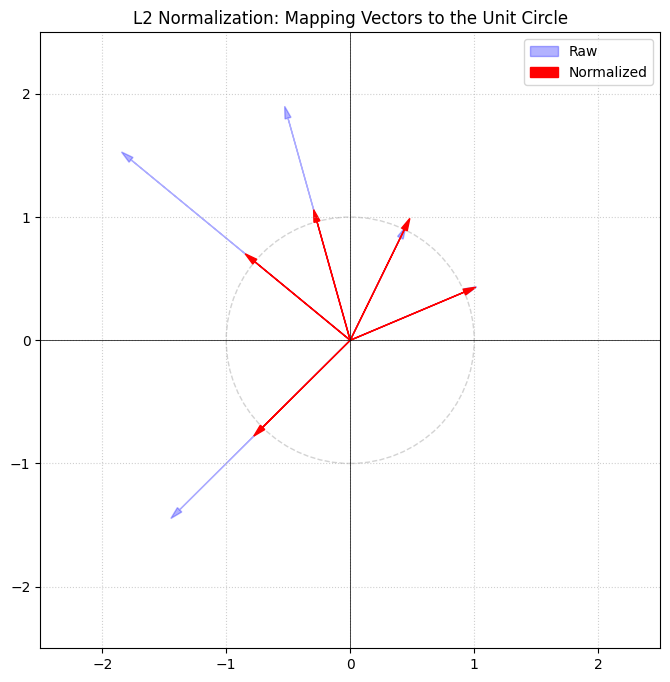

In [ ]:
# Create 5 random 2D vectors
np.random.seed(42)
raw_vectors = np.random.uniform(-2, 2, (5, 2))

# Normalize them
norms = np.linalg.norm(raw_vectors, axis=1, keepdims=True)
normalized_vectors = raw_vectors / norms

# Plotting
plt.figure(figsize=(8, 8))

# Draw Unit Circle
circle = plt.Circle((0, 0), 1, color='lightgray', fill=False, linestyle='--')
plt.gca().add_patch(circle)

# Plot Raw Vectors (Dashed arrows)
for i, v in enumerate(raw_vectors):
    plt.arrow(0, 0, v[0], v[1], head_width=0.05, head_length=0.1, fc='blue', ec='blue', alpha=0.3, label='Raw' if i == 0 else "")

# Plot Normalized Vectors (Solid arrows)
for i, v in enumerate(normalized_vectors):
    plt.arrow(0, 0, v[0], v[1], head_width=0.05, head_length=0.1, fc='red', ec='red', label='Normalized' if i == 0 else "")

plt.xlim(-2.5, 2.5)
plt.ylim(-2.5, 2.5)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.title("L2 Normalization: Mapping Vectors to the Unit Circle")
plt.show()

## Putting it all together: Simple Semantic Search
Now that we have embeddings for our sentences, we can build a very basic "Search Engine." When a user enters a query, we:
1. Encode the query into a vector.
2. Calculate similarity between the query vector and all stored vectors.
3. Return the sentence with the highest similarity.

In [11]:
def semantic_search(query, stored_sentences, stored_embeddings):
    # 1. Encode query
    query_embedding = model.encode([query])

    # 2. Calculate similarities
    query_similarities = model.similarity(query_embedding, stored_embeddings)[0]

    # 3. Find the best match
    best_idx = np.argmax(query_similarities)

    print(f"Query: \"{query}\"")
    print(f"Best Match: \"{stored_sentences[best_idx]}\"")
    print(f"Confidence Score: {query_similarities[best_idx]:.4f}")

# Try it out!
semantic_search("It is a bright and sunny day", sentences, embeddings)
print("-" * 30)
semantic_search("My pet is making noise", sentences, embeddings)

Query: "It is a bright and sunny day"
Best Match: "The weather is really good and sunny today."
Confidence Score: 0.7934
------------------------------
Query: "My pet is making noise"
Best Match: "My dog is barking and running around."
Confidence Score: 0.6739
